In [1]:
using CovidSim_ilm

[ Info: Precompiling CovidSim_ilm [c70e2dfc-8e06-4fce-bc57-ad774aa1cb0a]


In [2]:
using StatsBase
using TypedTables
using BenchmarkTools
export @ballocated, @belapsed, @benchmark, @benchmarkable, @benchmarkset, @bprofile, @btime, @case, @tagged, BenchmarkGroup, BenchmarkTools, addgroup!, allocs, gctime, improvements, invariants, isimprovement, isinvariant, isregression, judge, leaves, loadparams!, mean, median, memory, params, ratio, regressions, rmskew, rmskew!, trim, tune!, warmup
using Distributions
using YAML
using PrettyPrint

In [4]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/src"))

# Test setup and population matrix

In [5]:
# set locale and number of days
locale = 38015
ndays = 180

180

In [6]:
alldat = setup(ndays, [locale]; paramdir="../parameters", 
    geofilename="../data/geo2data.csv",
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml"
    );

LoadError: UndefKeywordError: keyword argument `day1` not assigned

In [8]:
alldat.transitionset # the decision transition matrices for all age groups are loaded

Dict{Any, Any} with 2 entries:
  :alpha => Dict{agegrp, Dict{Int64, Dict{Symbol, Any}}}(age80_up=>Dict(5=>Dict…
  :base  => Dict{agegrp, Dict{Int64, Dict{Symbol, Any}}}(age80_up=>Dict(5=>Dict…

In [9]:
dectree = alldat.transitionset[:base]

Dict{agegrp, Dict{Int64, Dict{Symbol, Any}}} with 5 entries:
  age80_up => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age20_39 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age0_19  => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age40_59 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age60_79 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …

In [10]:
dectree[age80_up]

Dict{Int64, Dict{Symbol, Any}} with 5 entries:
  5 => Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.682 0.0 … 0.0…
  4 => Dict(:transition=>[1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0…
  2 => Dict(:transition=>[0.5 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.4 0…
  3 => Dict(:transition=>[0.7 0.0 … 0.0 0.0; 0.7 0.0 … 0.0 0.0; 0.7 0.0 … 0.2 0…
  1 => Dict(:transition=>[0.0 0.1 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0…

In [11]:
dectree[age80_up][5]

Dict{Symbol, Any} with 2 entries:
  :transition => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.682 0.0 … 0.0 0.318; …
  :duration    => 25

In [12]:
trarr = copy(dectree[age80_up][5][:transition])

4×6 OffsetArray(::Matrix{Float64}, 5:8, 1:6) with eltype Float64 with indices 5:8×1:6:
 0.0    0.0  0.0  0.0  0.0  0.0
 0.0    0.0  0.0  0.0  0.0  0.0
 0.682  0.0  0.0  0.0  0.0  0.318
 0.676  0.0  0.0  0.0  0.0  0.324

In [13]:
axes(trarr, 1)

OffsetArrays.IdOffsetRange(values=5:8, indices=5:8)

In [14]:
function adjust_transition!(trarr, delta= 0.05)
    r, c = size(trarr)
    half = round(Int, c/2)
    adjvec = reshape(zeros(c), 1, c)
    prev_val = 0
    for i = 1:c
        if i <= half
            val = 1.0 + float(i) * delta
            prev_val = val
        else
            val = prev_val - float(i) * delta
        end
        adjvec[1, i] = val
    end

    for i in axes(trarr, 1)
        rowsum = sum(trarr[i,:])
        if rowsum != 0.0
            for c in axes(trarr,2)
                trarr[i, c] *= adjvec[c]
            end
            nf = 1.0 / sum(trarr[i,:])
            trarr[i,:] .*= nf
        end
    end
end

adjust_transition! (generic function with 2 methods)

In [41]:
function adjust_transition2!(trarr; vaxtreffect= 0.9, vaxdiscount=0.5)
    for i in axes(trarr, 1)
        rowsum = sum(trarr[i,:])
        if rowsum != 0.0
            for c in (sick, severe, dead)
                trarr[i, CovidSim_ilm.map2outcome(c)] *= (1.0 - vaxtreffect)
            end
            nf = 1.0 / sum(trarr[i,:])
            trarr[i,:] .*= nf
        end
    end
end

adjust_transition2! (generic function with 3 methods)

In [42]:
@btime adjust_transition2!($trarr); 

  297.456 ns (12 allocations: 960 bytes)


In [19]:
trarr

4×6 OffsetArray(::Matrix{Float64}, 5:8, 1:6) with eltype Float64 with indices 5:8×1:6:
 0.0       0.0  0.0  0.0  0.0  0.0
 0.0       0.0  0.0  0.0  0.0  0.0
 0.95545   0.0  0.0  0.0  0.0  0.0445503
 0.954263  0.0  0.0  0.0  0.0  0.0457369

In [46]:
chgvec .* trarr

4×6 OffsetArray(::Matrix{Float64}, 5:8, 1:6) with eltype Float64 with indices 5:8×1:6:
 0.0     0.0  0.0  0.0  0.0  0.0
 0.0     0.0  0.0  0.0  0.0  0.0
 0.7161  0.0  0.0  0.0  0.0  0.276522
 0.7098  0.0  0.0  0.0  0.0  0.281739

In [47]:
sum(chgvec .* trarr, dims=2)

4×1 OffsetArray(::Matrix{Float64}, 5:8, 1:1) with eltype Float64 with indices 5:8×1:1:
 0.0
 0.0
 0.9926217391304348
 0.9915391304347827

In [33]:
dectree[age80_up][5][:transition][nil, :]

6-element OffsetArray(::Vector{Float64}, 1:6) with eltype Float64 with indices 1:6:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

# Create a seed case

In [8]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, :nil, :base, agegrps)

LoadError: UndefVarError: `agegrps` not defined

# Run a simulation

In [5]:
ndays = 180
locale = 38015
model = buildsim(ndays, locale;  
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml",
);

In [28]:
typeof(model)

NamedTuple{(:ndays, :locales, :dat, :transitionset, :geo, :vaxset, :variants, :vaxschedset, :infectset, :social, :trvec), Tuple{Int64, Vector{Int64}, Dict{String, Dict{Int64}}, Dict{Any, Any}, DataFrames.DataFrame, Nothing, Dict{Symbol, Any}, Nothing, Dict{Symbol, Infectparams}, CovidSim_ilm.Socialparams, Vector{Float64}}}

In [6]:
popdat, series = runsim(model;
            runcases=[seed_1_6]
            );

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.16562722000000013, 0, 0.5963339580000002, 0.4059444219999999, 0.8167524090000006)


In [30]:
keys(model)

(:ndays, :locales, :dat, :transitionset, :geo, :vaxset, :variants, :vaxschedset, :infectset, :social, :trvec)

In [31]:
keys(popdat)

KeySet for a Dict{Int64, Table{NamedTuple{(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday), Tuple{Int64, status, agegrp, condition, Int64, Symbol, Int64, Int64, Int64, Symbol, Symbol, Vector{Symbol}, Vector{Int64}, Int64, Bool, Int64, Bool, Int64}}, 1, NamedTuple{(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday), Tuple{Vector{Int64}, Vector{status}, Vector{agegrp}, Vector{condition}, Vector{Int64}, Vector{Symbol}, Vector{Int64}, Vector{Int64}, Vector{Int64}, Vector{Symbol}, Vector{Symbol}, Vector{Vector{Symbol}}, Vector{Vector{Int64}}, Vector{Int64}, BitVector, Vector{Int64}, BitVector, Vector{Int64}}}}} with 1 entry. Keys:
  38015

In [32]:
keys(series)

KeySet for a Dict{Int64, Dict{Symbol, Matrix{Int64}}} with 1 entry. Keys:
  38015

In [10]:
model.dat

Dict{String, Dict{Int64}} with 4 entries:
  "agegrp_idx" => Dict{Int64, Dict{agegrp, Vector{Int64}}}(38015=>Dict(age0_19=…
  "newhistmx"  => Dict{Int64, Array{Int64}}(38015=>[0 0 … 0 0; 0 0 … 0 0; … ; -…
  "popdat"     => Dict{Int64, Table{NamedTuple{(:pid, :status, :agegrp, :cond, …
  "cumhistmx"  => Dict{Int64, Array{Int64}}(38015=>[24002 25912 … 0 0; 24002 25…

In [33]:
popdat[locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond        duration  variant  recovday  ⋯
    ┌───────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  uninfected  0        base     0         ⋯
 2  │ 2    unexposed  age0_19  uninfected  0        base     0         ⋯
 3  │ 3    recovered  age0_19  mild        14       base     172       ⋯
 4  │ 4    unexposed  age0_19  uninfected  0        base     0         ⋯
 5  │ 5    recovered  age0_19  mild        14       base     112       ⋯
 6  │ 6    recovered  age0_19  sick        14       base     172       ⋯
 7  │ 7    unexposed  age0_19  uninfected  0        base     0         ⋯
 8  │ 8    recovered  age0_19  mild        14       base     93        ⋯
 9  │ 9    unexposed  age0_19  uninfected  0        base     0         ⋯
 10 │ 10   recovered  age0_19  mild        14       base     150       ⋯
 11 │ 11   unexposed  age0_19  uninfected  0        base     0         ⋯
 12 │ 12   r

In [7]:
locdat = popdat[locale]
countmap(locdat.cond)

Dict{condition, Int64} with 5 entries:
  uninfected => 16913
  nil        => 15167
  mild       => 40980
  severe     => 3788
  sick       => 18778

In [8]:
countmap(locdat.status)

Dict{status, Int64} with 4 entries:
  infectious => 3318
  recovered  => 74008
  dead       => 1387
  unexposed  => 16913

In [13]:
virus_outcome(series, locale, base=:pop)

Dict{Symbol, Float64} with 4 entries:
  :infectious => 0.0317487
  :dead       => 0.0145253
  :recovered  => 0.775093
  :unexposed  => 0.178633

In [38]:
keys(series[locale])

KeySet for a Dict{Symbol, Matrix{Int64}} with 2 entries. Keys:
  :cum
  :new

In [24]:
println(":cum ", typeof(series[locale][:cum]))
println(":cum ", size(series[locale][:cum]))
println(":new ", size(series[locale][:new]))

:cum Matrix{Int64}
:cum (180, 108)
:new (180, 108)


In [15]:
series[locale][:cum]

180×108 Matrix{Int64}:
 24002  25912  24382  17595  3729  …  0  0  0  0  0  0  0  0  0  0  0  0
 24002  25912  24382  17595  3729     0  0  0  0  0  0  0  0  0  0  0  0
 24001  25912  24382  17594  3729     0  0  0  0  0  0  0  0  0  0  0  0
 24001  25910  24381  17594  3729     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25910  24380  17593  3729     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25908  24379  17593  3729  …  0  0  0  0  0  0  0  0  0  0  0  0
 24000  25907  24378  17592  3729     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25903  24377  17592  3729     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25902  24373  17592  3728     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25900  24371  17590  3727     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25900  24371  17589  3726  …  0  0  0  0  0  0  0  0  0  0  0  0
 24000  25900  24368  17588  3726     0  0  0  0  0  0  0  0  0  0  0  0
 24000  25898  24367  17587  3726     0  0  0  0  0  0  0  0  0  0  0  0
     ⋮                      

# Plotted results

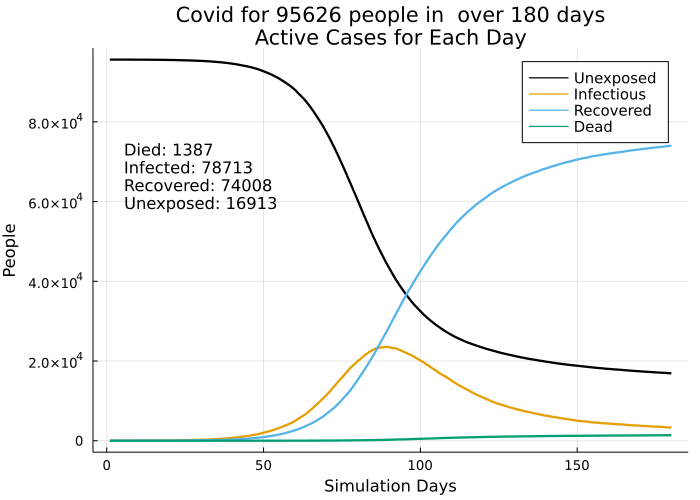

In [9]:
cumplot(series, locale)

Note that the orangle line labeled Infectious that shows the number of infected people is *not* what you see in newspaper accounts. In this plot Infectious shows the net infected people: Some people got sick today. Some people get better: they're not infectious any more--they recovered and are on the blue line. Sadly, some people died--they're not infectious either--they're dead and are on the green line. Newspaper tracking shows the new active infections of each day--who got sick today? The next day, if no one new got sick the line would be at zero--even though the people who got sick aren't better yet. So, the newspaper line goes up and down faster. Yet another approach is to show the cumulative number of infected people: This keeps going up until no one new gets infected--then the line is high but levels off. This is the least common way to show the data.

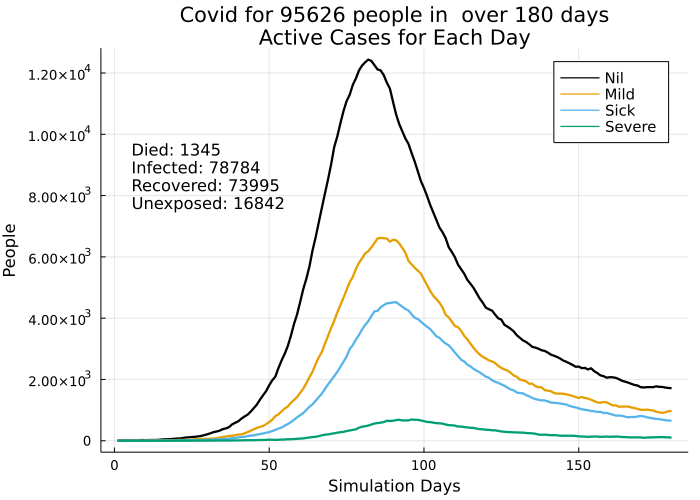

In [40]:
cumplot(series, locale, [:nil, :mild, :sick, :severe])

## Test a social distancing case

In [52]:
sd1 = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, include_ages=[])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Any}}}) (generic function with 1 method)

In [53]:
sd1_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, include_ages=[])

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{Any}}}) (generic function with 1 method)

In [ ]:
result_dict, series = run_a_sim(ndays, locale, showr0=false, silent=true, runcases=[seed_1_6, sd1, sd1_end]);

In [ ]:
virus_outcome(series, locale, base=:pop)

In [ ]:
cumplot(series, locale)

In [ ]:
cumplot(series, locale,[:infectious, :dead])

In [ ]:
outdat = result_dict.dat["popdat"][locale]
all(outdat.sdcomply .== :none)

## Social distancing only among those age40_59, age60_79, age80_plus

In [44]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [45]:
sdolder_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [46]:
popdat, series = runsim(model; 
                    runcases=[seed_1_6, sdolder, sdolder_end]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.028017789000000008, 0, 0.30671812000000004, 0.26435500200000006, 0.263085712)


In [47]:
olderdat =popdat[locale]

sd = findall(olderdat.sdcomply .!= :none)

@Select(agegrp, sdcomply)(olderdat[sd])

Table with 2 columns and 0 rows:
     agegrp  sdcomply
   ┌─────────────────

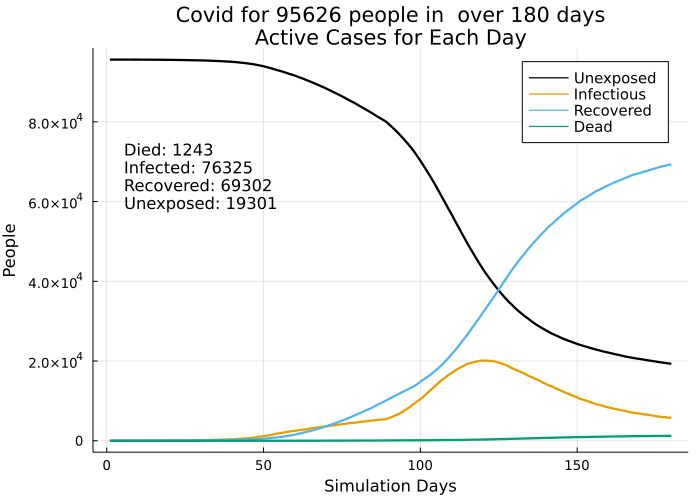

In [48]:
cumplot(series, locale)

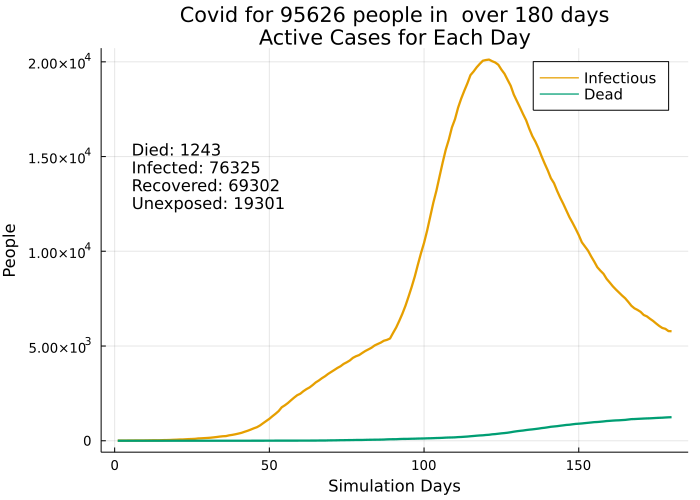

In [49]:
cumplot(series, locale, [:infectious, :dead])

## Social Distancing starts with everyone and then the younger folks party

In [50]:
sdyoung_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age0_19, age20_39])    

(::CovidSim_ilm.var"#runcase#105"{CovidSim_ilm.var"#runcase#104#106"{Int64, Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}, Symbol, Vector{agegrp}}}) (generic function with 1 method)

In [54]:
popdat, series = runsim(model,
    runcases=[seed_1_6, sd1, sdyoung_end]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.050828589, 0, 0.07982246500000001, 0.07125303400000003, 0.25339804099999996)


In [55]:
mixdat = popdat[locale]

sd = findall(mixdat.sdcomply .!= :none)
young = findall((mixdat.agegrp .== age0_19) .| (mixdat.agegrp .== age20_39))
sd_young_idx = intersect(sd, young)
old = findall((mixdat.agegrp .== age40_59) .| (mixdat.agegrp .== age60_79) .| (mixdat.agegrp .== age80_up));

In [56]:
youngtab = Table(mixdat[young])
count(youngtab.sdcomply .== :none)

49917

In [57]:
oldtab = Table(mixdat[old])
count(oldtab.sdcomply .!= :none)

40951

In [58]:
typeof(mixdat.agegrp)

Vector{agegrp} (alias for Array{agegrp, 1})

In [59]:
mixdat = popdat[locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond        duration  variant  recovday  ⋯
    ┌───────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  uninfected  0        base     0         ⋯
 2  │ 2    unexposed  age0_19  uninfected  0        base     0         ⋯
 3  │ 3    unexposed  age0_19  uninfected  0        base     0         ⋯
 4  │ 4    unexposed  age0_19  uninfected  0        base     0         ⋯
 5  │ 5    unexposed  age0_19  uninfected  0        base     0         ⋯
 6  │ 6    unexposed  age0_19  uninfected  0        base     0         ⋯
 7  │ 7    unexposed  age0_19  uninfected  0        base     0         ⋯
 8  │ 8    unexposed  age0_19  uninfected  0        base     0         ⋯
 9  │ 9    unexposed  age0_19  uninfected  0        base     0         ⋯
 10 │ 10   unexposed  age0_19  uninfected  0        base     0         ⋯
 11 │ 11   unexposed  age0_19  uninfected  0        base     0         ⋯
 12 │ 12   u

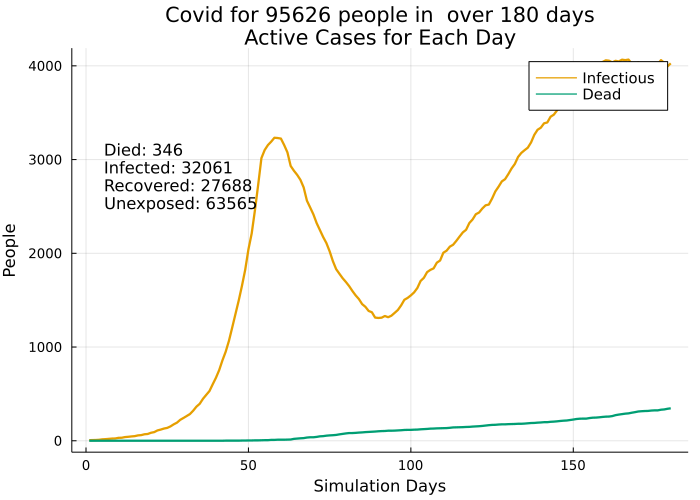

In [60]:
cumplot(series, locale, [:infectious, :dead])

In [61]:
@Select(status, agegrp, cond, sdcomply)(locdat)

Table with 4 columns and 95626 rows:
      status     agegrp   cond        sdcomply
    ┌─────────────────────────────────────────
 1  │ unexposed  age0_19  uninfected  none
 2  │ unexposed  age0_19  uninfected  none
 3  │ recovered  age0_19  mild        none
 4  │ unexposed  age0_19  uninfected  none
 5  │ recovered  age0_19  mild        none
 6  │ recovered  age0_19  sick        none
 7  │ unexposed  age0_19  uninfected  none
 8  │ recovered  age0_19  mild        none
 9  │ unexposed  age0_19  uninfected  none
 10 │ recovered  age0_19  mild        none
 11 │ unexposed  age0_19  uninfected  none
 12 │ recovered  age0_19  mild        none
 13 │ recovered  age0_19  nil         none
 14 │ recovered  age0_19  nil         none
 15 │ recovered  age0_19  nil         none
 16 │ unexposed  age0_19  uninfected  none
 17 │ recovered  age0_19  mild        none
 18 │ recovered  age0_19  nil         none
 19 │ unexposed  age0_19  uninfected  none
 20 │ unexposed  age0_19  uninfected  none
 21 │ une

alldat

In [ ]:
alldat

In [ ]:
ages = alldat.dat["agegrp_idx"][locale]

In [ ]:
include_ages = [age0_19, age20_39]

In [ ]:
union((ages[i] for i in include_ages)...)

In [ ]:
locdat.sdcomply[collect(1:5:95000)] .= :test

In [ ]:
incase_idx = findall(locdat.sdcomply .== :test)

In [ ]:
byage_idx = intersect(incase_idx, union((ages[i] for i in include_ages)...))

In [ ]:
function maketup(keys, values)
    NamedTuple{keys}(values)
end

In [ ]:
mapconds = maketup((:nil, :mild, :sick, :severe), [5,6,7,8])

In [ ]:
typeof(mapconds)

In [ ]:
keys(mapconds)

In [ ]:
eltype(values(mapconds))

In [ ]:
using BenchmarkTools
@btime $mapconds.nil

In [ ]:
function mapvec(maptup, vals)
    [getfield(maptup, x) for x in vals]
end

In [ ]:
typeof(mapvec)

In [ ]:
vals = [nil, sick]
mapvec(mapconds, Symbol.(vals))

In [ ]:
using Markdown
println(md"*bold*")

In [ ]:
map2series

In [ ]:
getindex(map2series, :unexposed)

In [ ]:
getindex(Dict("a"=>1, "b"=>2, "c"=>3), "a")